In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# pip install pyarrow and dask
import dask.dataframe as dd
sns.set(rc={'axes.facecolor':'grey'})

In [53]:
# Importing the data
region = ['south_sudan', 'eastern_east_africa', 'eastern_ukraine', 'southern_africa', 'west_africa', 'sri_lanka', 'lake_victoria_basin']
model = ['CanESM5', 'CCSM4', 'CESM1', 'GEM5', 'GFDL', 'NASA', 'NCEP', 'DWD', 'ECMWF', 'METEO']
for i in region:
    for j in model:
        globals()['{}_{}'.format(i, j)] = xr.open_mfdataset('data/netCDF/{}_{}_merged.nc'.format(i, j)).to_dataframe().reset_index()

In [15]:
# Spatial means precip and predicted precip of each region, grouped by time and lead time
for i in region:
    for j in model:
        # Calculate ensemble mean
        globals()['{}_{}_ensemble_means'.format(i, j)] = (globals()['{}_{}'.format(i, j)]
                                                         .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                                                         .mean().reset_index())
        # Calculate the spatial means for each region and model
        globals()['{}_{}_spatial_means'.format(i, j)] = (globals()['{}_{}_ensemble_means'.format(i, j)]
                                                         .groupby(['time', 'lead_time'])[['predicted_precip', 'precip']]
                                                         .mean().reset_index())
        # Extract months
        globals()['{}_{}_spatial_means'.format(i, j)]['month'] = globals()['{}_{}_spatial_means'.format(i, j)]['time'].dt.month
        # Calculate the correlation between predicted precip and precip means
        globals()['{}_{}_spatial_means_corr'.format(i, j)] = (globals()['{}_{}_spatial_means'.format(i, j)]
                                                              .groupby(['month', 'lead_time'])[['predicted_precip', 'precip']].corr(method = 'spearman')
                                                              .iloc[0::2, -1].droplevel(level = 2).reset_index())
        globals()['{}_{}_spatial_means_corr'.format(i, j)]['region'] = i
        globals()['{}_{}_spatial_means_corr'.format(i, j)]['model'] = j

In [19]:
# Concatenate all the dataframes
spatial_means_corr = pd.concat([globals()['{}_{}_spatial_means_corr'.format(i, j)] for i in region for j in model], ignore_index = True)
spatial_means_corr = spatial_means_corr.rename(columns = {'precip': 'corr'})
spatial_means_corr

,month,lead_time,corr,region,model
0,1,0.5,0.475417,south_sudan,CanESM5
1,1,1.5,0.242269,south_sudan,CanESM5
2,1,2.5,-0.043826,south_sudan,CanESM5
3,1,3.5,0.179533,south_sudan,CanESM5
4,1,4.5,-0.074082,south_sudan,CanESM5
...,...,...,...,...,...
8143,12,2.0,0.442365,lake_victoria_basin,METEO
8144,12,3.0,0.254187,lake_victoria_basin,METEO
8145,12,4.0,0.241379,lake_victoria_basin,METEO
8146,12,5.0,0.232020,lake_victoria_basin,METEO


In [63]:
#heatmap 
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs, vmin=-0.7, vmax=0.7,
                cmap=sns.color_palette('vlag', 15),
                linewidths=0.1, linecolor='black')
    plt.xticks(np.arange(0.5, 12.5, 1))  # Set xticks explicitly
    plt.gca().set_xticklabels(np.arange(0.5, 12.5, 1))  # Set xticklabels
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.gca().invert_yaxis()

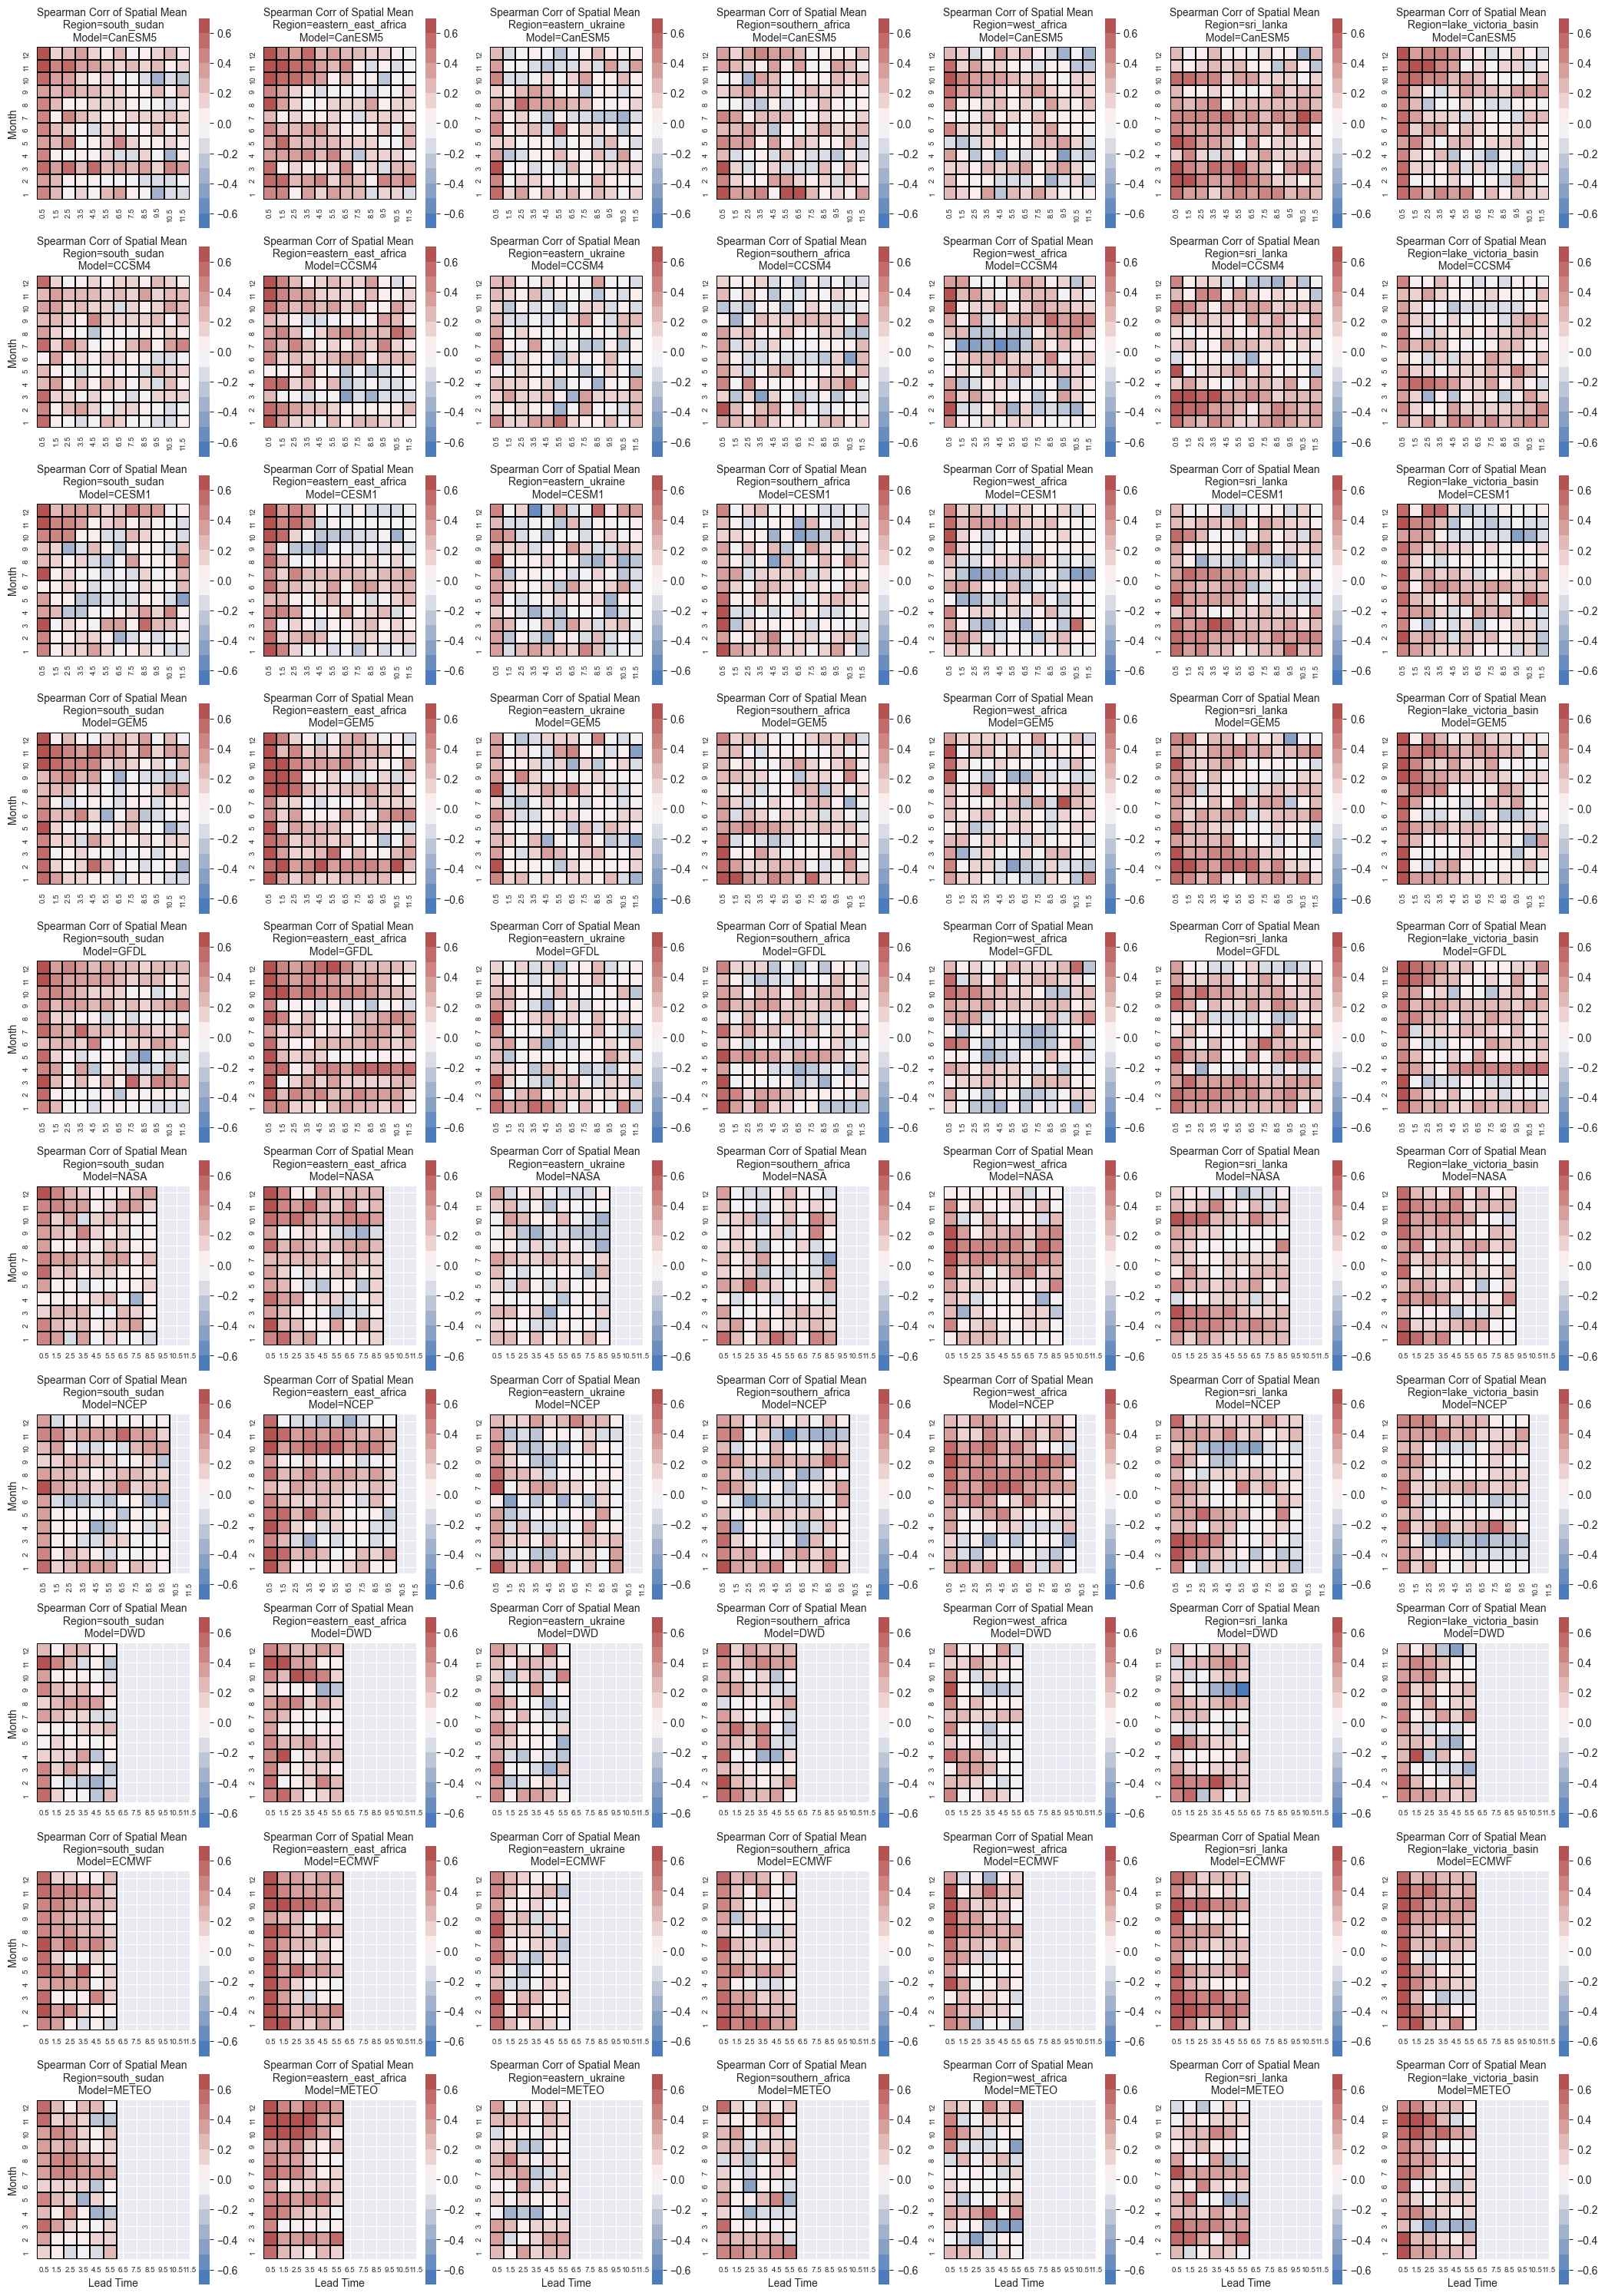

In [22]:
fg = sns.FacetGrid(spatial_means_corr, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

fg.set_titles('Spearman Corr of Spatial Mean \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/spatial_means_corr.png')

In [42]:
# Adding Dry Masking
dry_mask_months = {'south_sudan': [1,2,12],
                   'eastern_east_africa': [1,2],
                   'southern_africa': [5,6,7,8,9],
                   'west_africa': [1,2,3,11,12]}

spatial_means_corr_dm = spatial_means_corr

for index, row in spatial_means_corr_dm.iterrows():  # Iterate over rows
    region = row['region']
    month = row['month']

    if region in dry_mask_months and month in dry_mask_months[region]:
        spatial_means_corr_dm.loc[index, 'corr'] = np.nan  # Set 'corr' to 0 for the matching row

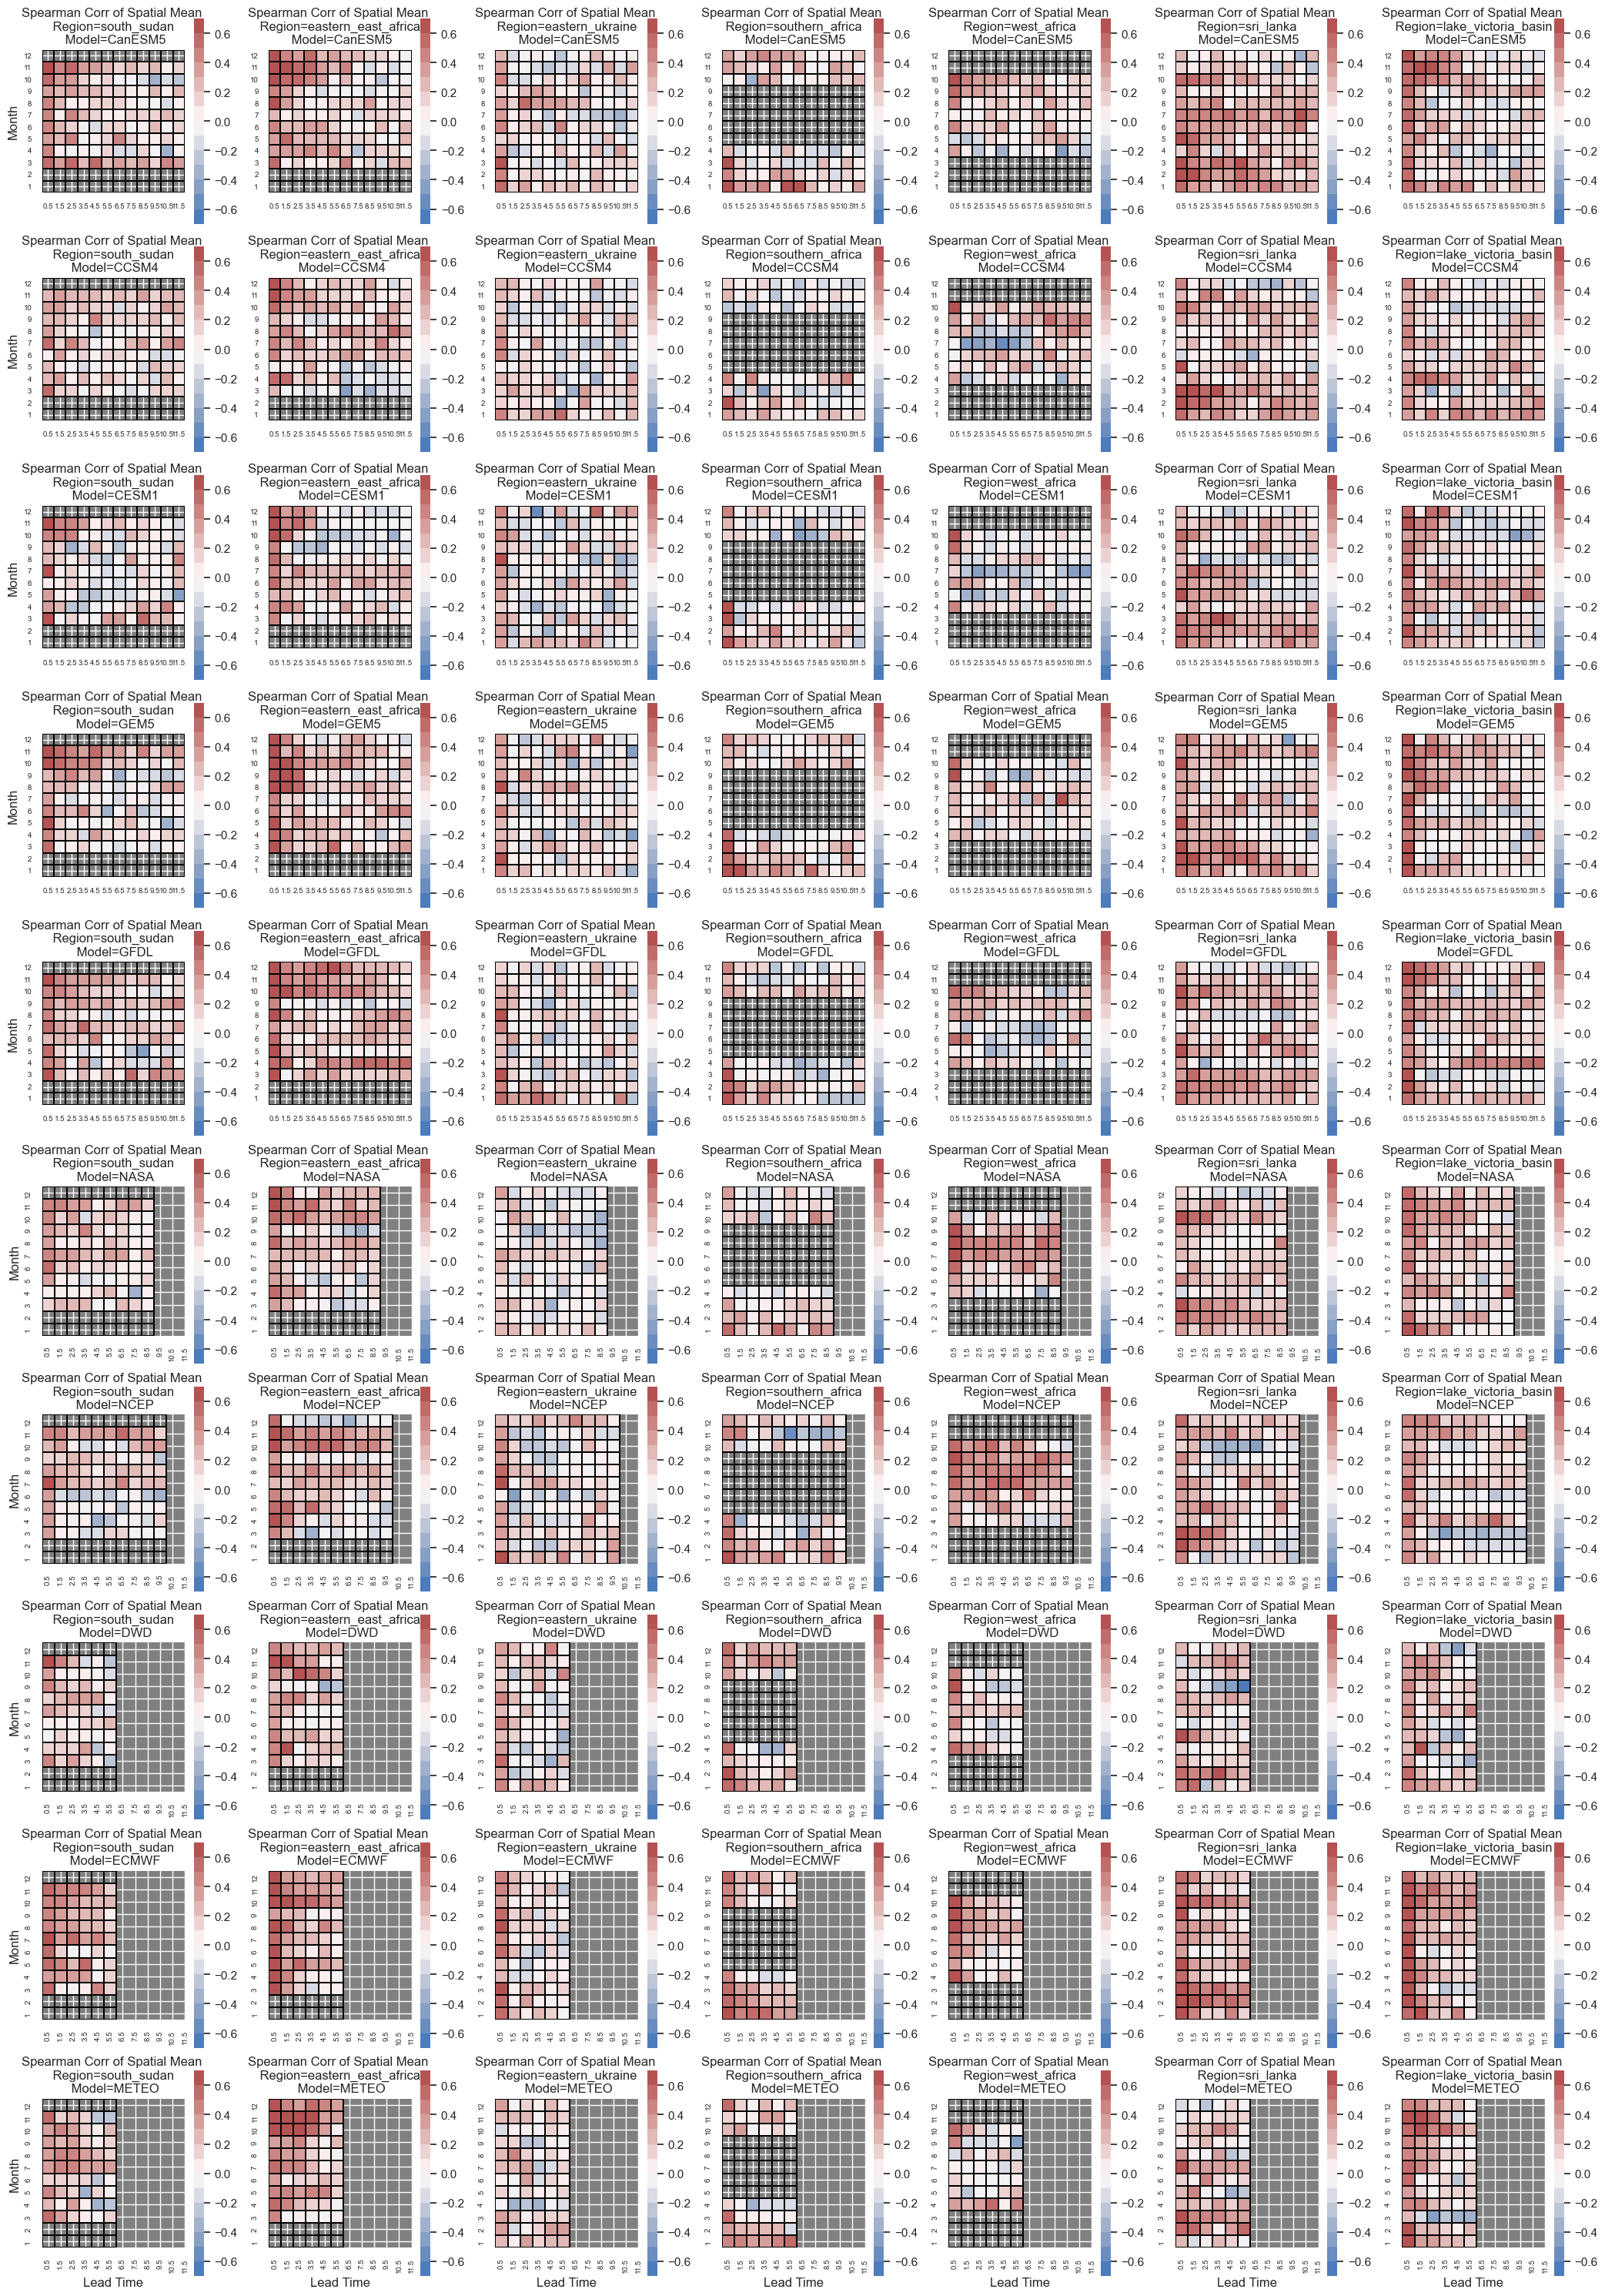

In [50]:
fg = sns.FacetGrid(spatial_means_corr_dm, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)
fg.set_titles('Spearman Corr of Spatial Mean \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/dry_masked_spatial_means_corr.png')

In [57]:
# Temporal means precip and predicted precip of each pixel, grouped by latitude, longitude, month and lead time
for i in region:
    for j in model:
        # Calculate ensemble mean
        globals()['{}_{}_ensemble_means'.format(i, j)] = (globals()['{}_{}'.format(i, j)]
                                                         .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                                                         .mean().reset_index())
        # Extract months
        globals()['{}_{}_ensemble_means'.format(i, j)]['month'] = globals()['{}_{}_ensemble_means'.format(i, j)]['time'].dt.month
        # Calculate the temporal means for each region and model
        globals()['{}_{}_temporal_means'.format(i, j)] = (globals()['{}_{}_ensemble_means'.format(i, j)]
                                                         .groupby(['latitude', 'longitude', 'month', 'lead_time'])[['predicted_precip', 'precip']]
                                                         .mean().reset_index())
        # Calculate the correlation between predicted precip and precip temporal means
        globals()['{}_{}_temporal_means_corr'.format(i, j)] = (globals()['{}_{}_temporal_means'.format(i, j)].groupby(['month', 'lead_time'])[['predicted_precip', 'precip']]
                                                               .corr(method = 'spearman').iloc[0::2, -1].droplevel(level = 2).reset_index())
        globals()['{}_{}_temporal_means_corr'.format(i, j)]['region'] = i
        globals()['{}_{}_temporal_means_corr'.format(i, j)]['model'] = j

In [58]:
# Concatenate all the dataframes, renaming precip to corr
temporal_means_corr = pd.concat([globals()['{}_{}_temporal_means_corr'.format(i, j)] for i in region for j in model], ignore_index = True)
temporal_means_corr = temporal_means_corr.rename(columns = {'precip': 'corr'})

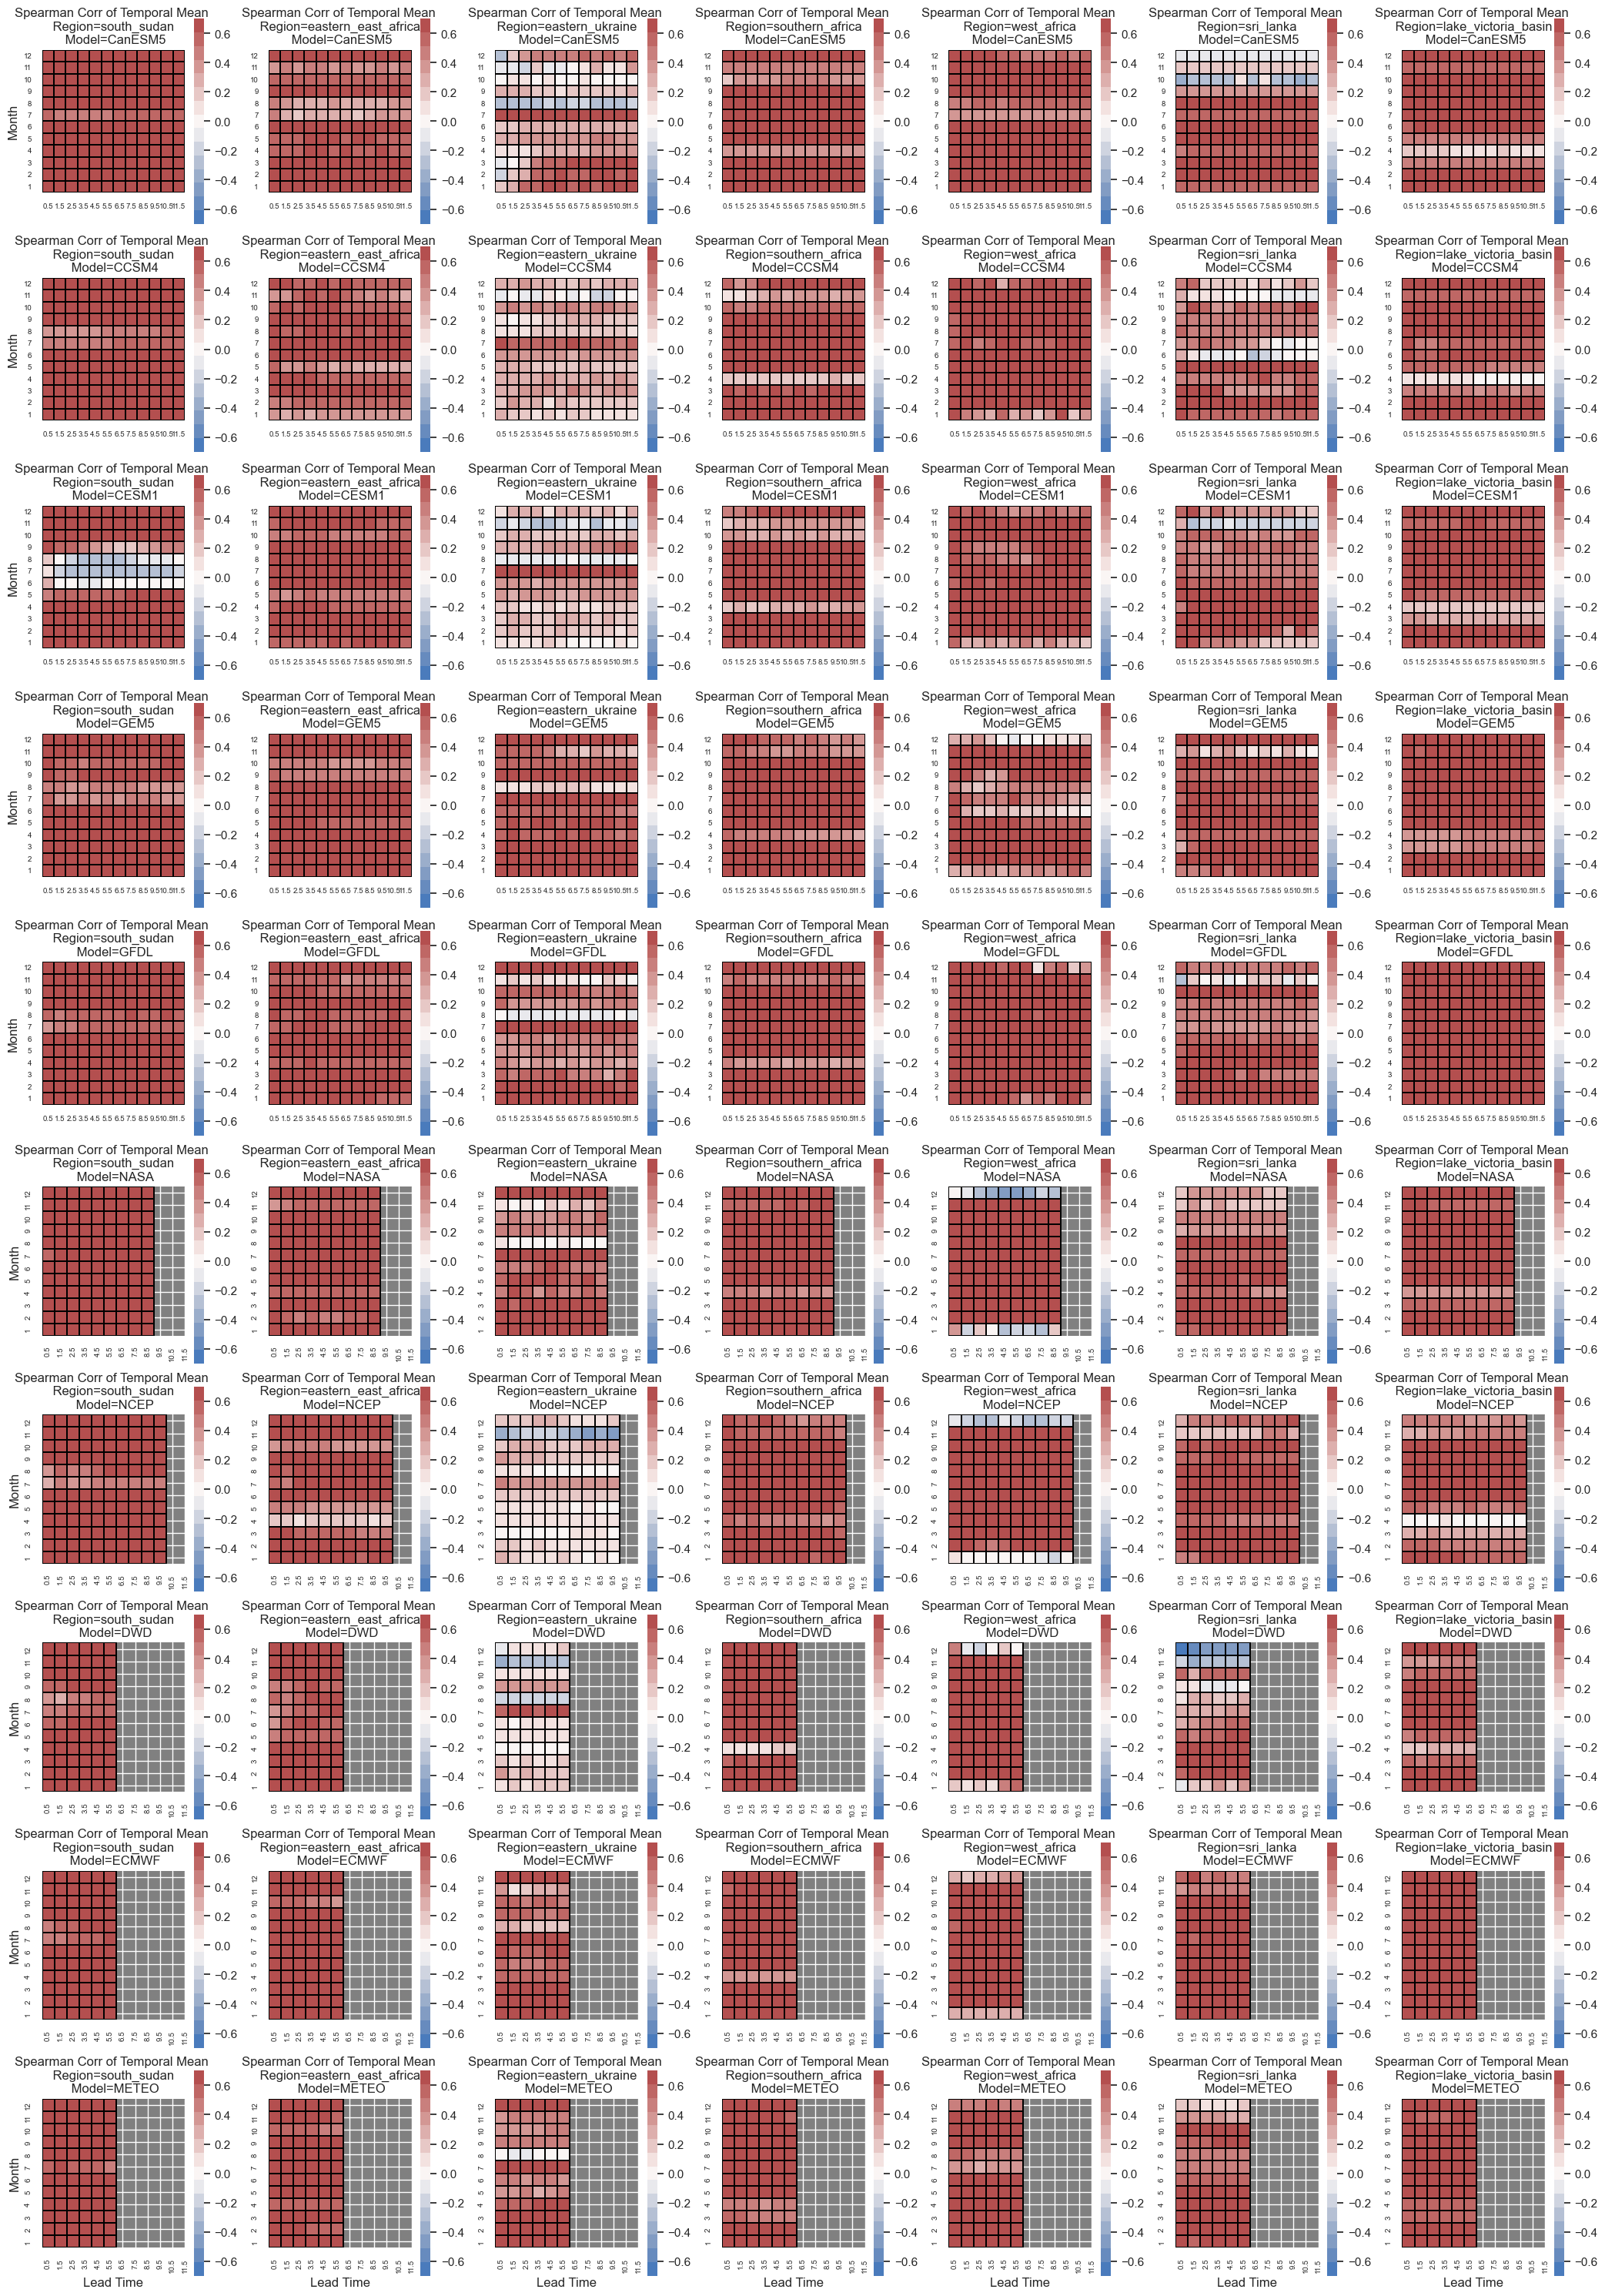

In [64]:
fg = sns.FacetGrid(temporal_means_corr, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

fg.set_titles('Spearman Corr of Temporal Mean \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/temporal_means_corr.png')

In [66]:
# Adding Dry Masking
dry_mask_months = {'south_sudan': [1,2,12],
                   'eastern_east_africa': [1,2],
                   'southern_africa': [5,6,7,8,9],
                   'west_africa': [1,2,3,11,12]}

temporal_means_corr_dm = temporal_means_corr

for index, row in temporal_means_corr_dm.iterrows():  # Iterate over rows
    region = row['region']
    month = row['month']

    if region in dry_mask_months and month in dry_mask_months[region]:
        temporal_means_corr_dm.loc[index, 'corr'] = np.nan  # Set 'corr' to 0 for the matching row

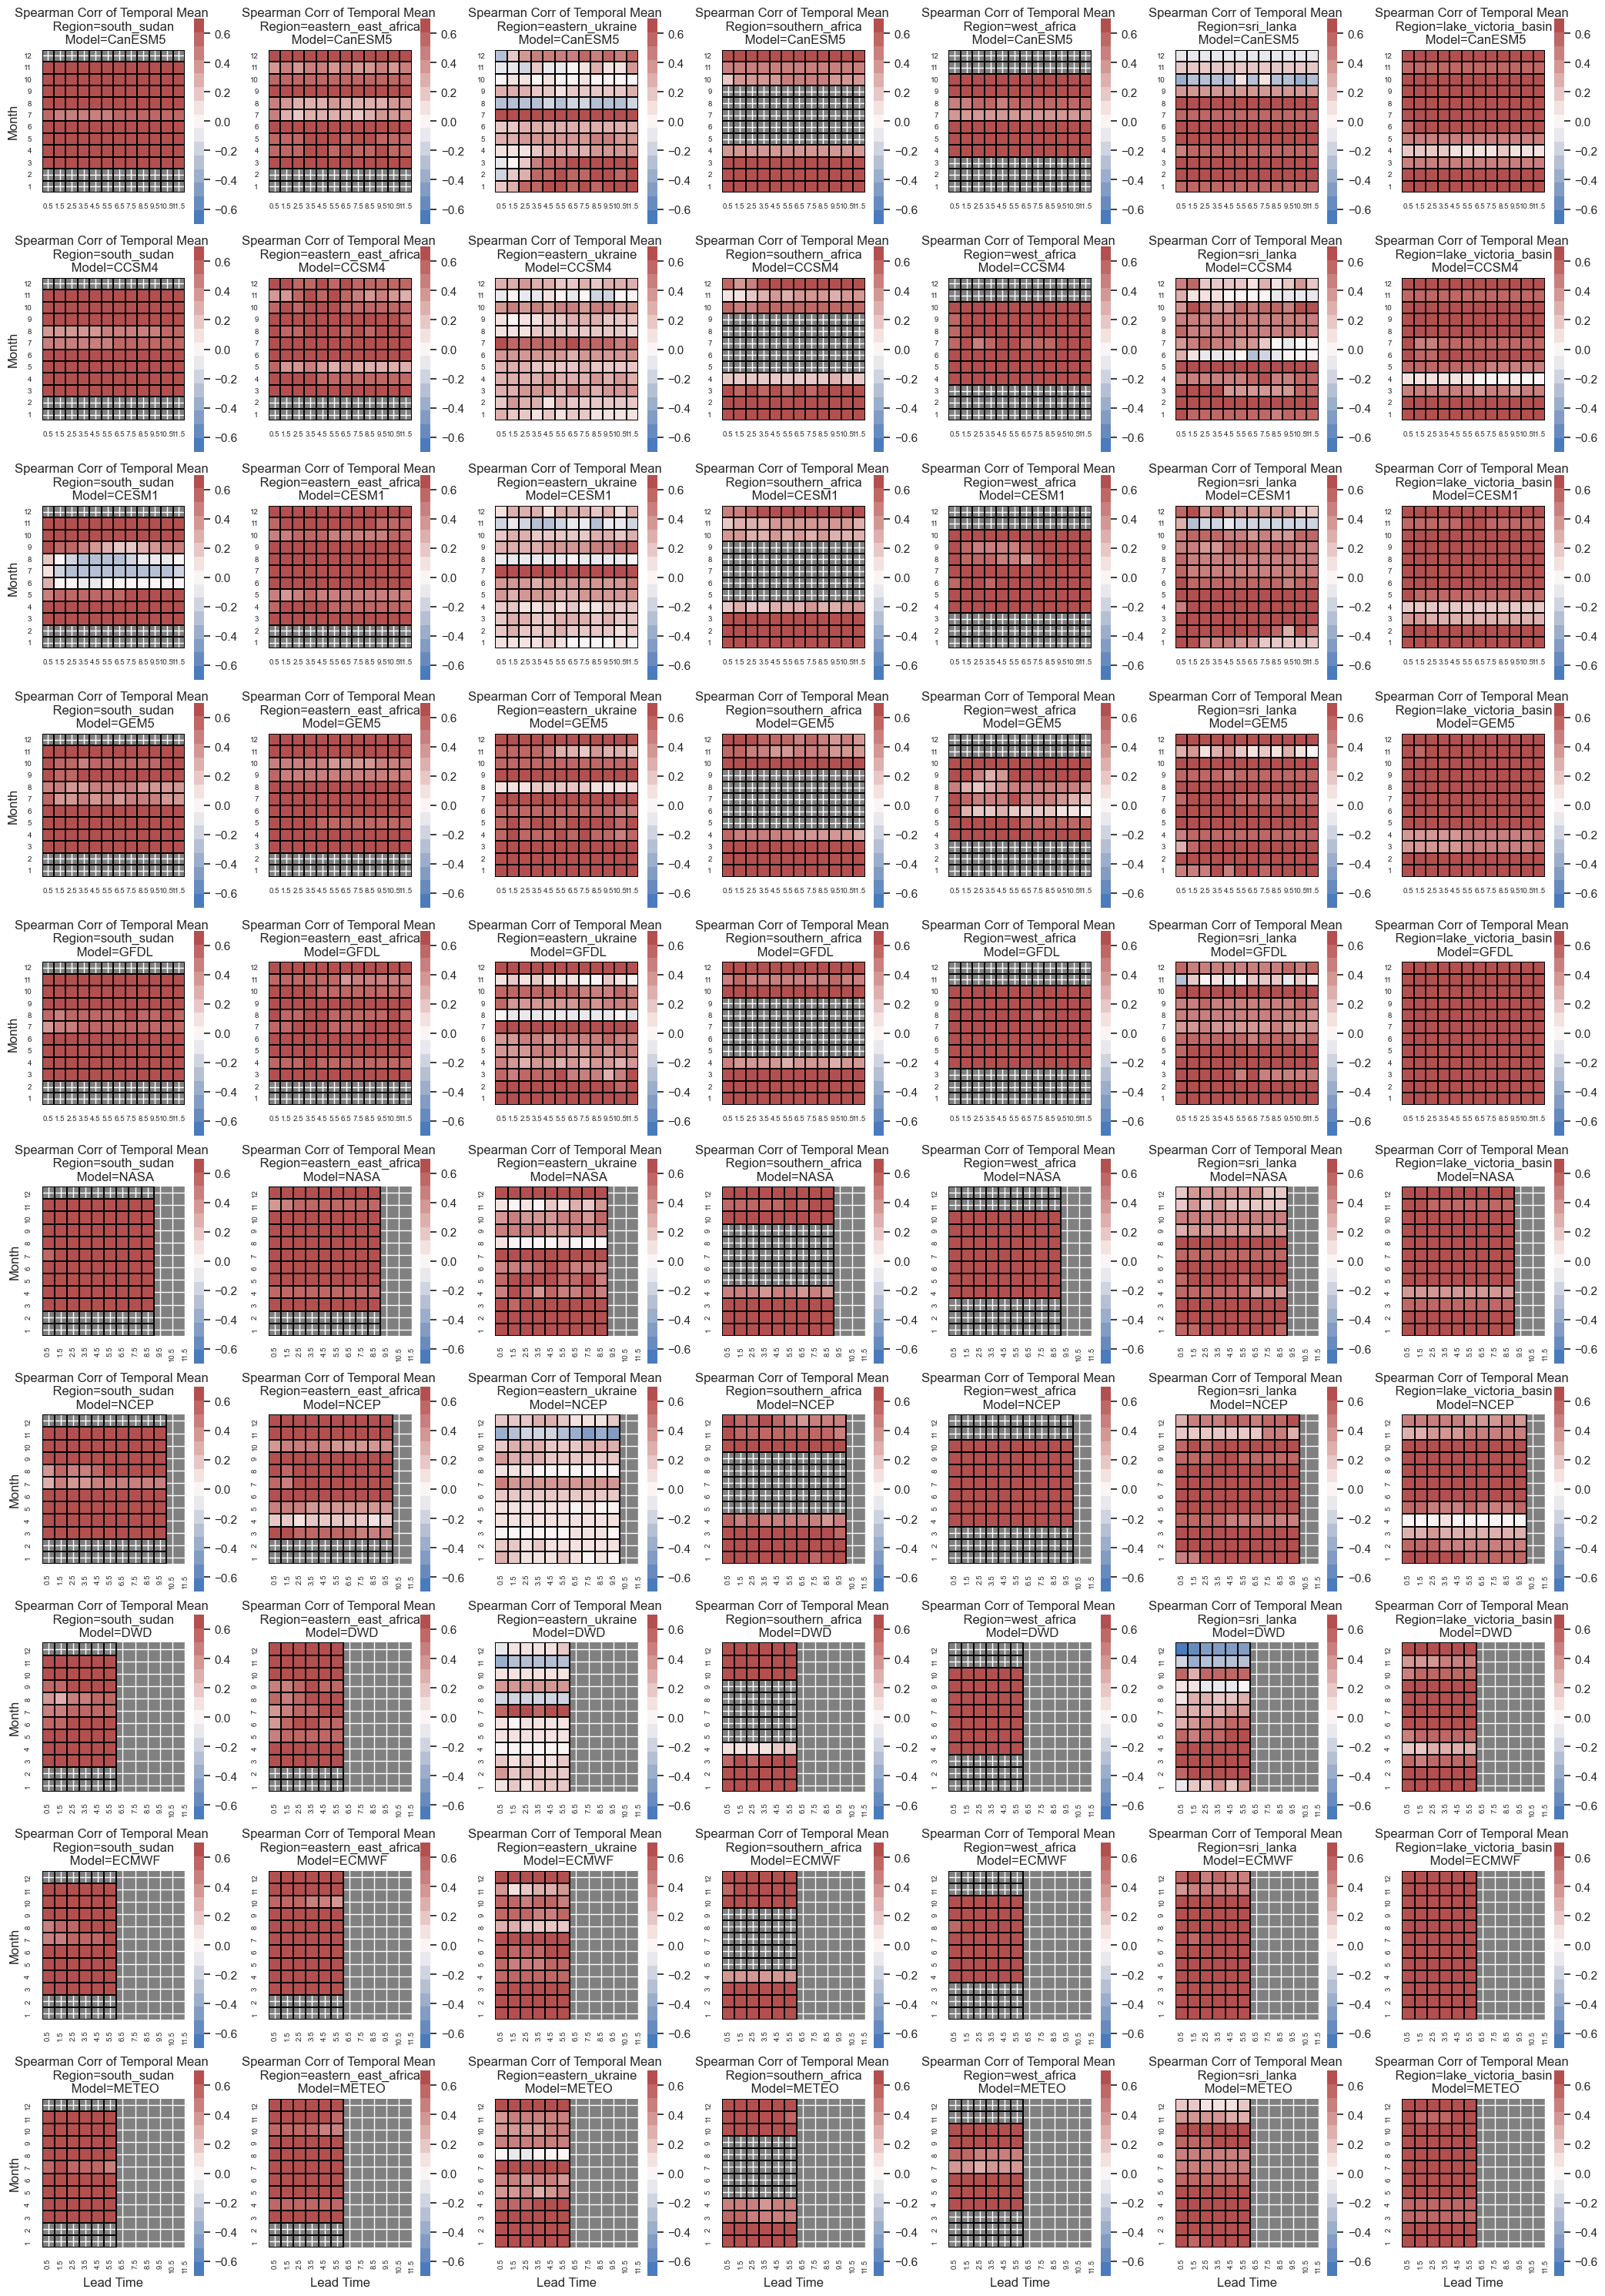

In [67]:
fg = sns.FacetGrid(temporal_means_corr_dm, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)
fg.set_titles('Spearman Corr of Temporal Mean \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/dry_masked_temporal_means_corr.png')